<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Abbate_et_al.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga del Modelo entrenado

In [1]:
!wget https://zenodo.org/records/15565400/files/EfficientNetV2S%20Trained%20Model%20Weights.zip

--2025-06-13 19:43:11--  https://zenodo.org/records/15565400/files/EfficientNetV2S%20Trained%20Model%20Weights.zip
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.48.194, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 227385399 (217M) [application/octet-stream]
Saving to: ‘EfficientNetV2S Trained Model Weights.zip’

EfficientNetV2S Tra 100%[===================>] 216.85M  24.1MB/s    in 11s     

2025-06-13 19:43:23 (19.0 MB/s) - ‘EfficientNetV2S Trained Model Weights.zip’ saved [227385399/227385399]



In [2]:
!unzip "/content/EfficientNetV2S Trained Model Weights.zip"

Archive:  /content/EfficientNetV2S Trained Model Weights.zip
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/assets/
 extracting: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/fingerprint.pb  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/keras_metadata.pb  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/saved_model.pb  
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/variables.data-00000-of-00001  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/variables.index  


In [3]:
!wget https://zenodo.org/records/15565400/files/Replication%20Data.zip

--2025-06-13 19:43:34--  https://zenodo.org/records/15565400/files/Replication%20Data.zip
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.48.194, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 852640867 (813M) [application/octet-stream]
Saving to: ‘Replication Data.zip’

Replication Data.zi 100%[===================>] 813.14M  26.6MB/s    in 37s     

2025-06-13 19:44:12 (21.9 MB/s) - ‘Replication Data.zip’ saved [852640867/852640867]



In [4]:
!unzip "/content/Replication Data.zip"

Archive:  /content/Replication Data.zip
   creating: Replication Data/
  inflating: Replication Data/ARG_2010_EPHC-S2_v03_M_v06_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2013_EPHC-S2_v03_M_v06_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2018_EPHC-S2_v01_M_v05_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2022_EPHC-S2_v01_M_v01_A_SEDLAC-03_all.dta  
  inflating: Replication Data/censo2010_fullraw_p.dta  
  inflating: Replication Data/deciles_2010.xlsx  
 extracting: Replication Data/income_estimates_2013.cpg  
  inflating: Replication Data/income_estimates_2013.dbf  
  inflating: Replication Data/income_estimates_2013.prj  
  inflating: Replication Data/income_estimates_2013.shp  
  inflating: Replication Data/income_estimates_2013.shx  
 extracting: Replication Data/income_estimates_2018.cpg  
  inflating: Replication Data/income_estimates_2018.dbf  
  inflating: Replication Data/income_estimates_2018.prj  
  inflating: Replication Data/income_estima

In [5]:
from keras.layers import TFSMLayer

# Ruta al directorio que contiene el modelo, no al archivo `.pb`
model_path = '/content/effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/'

# Cargar el modelo como capa inferencial
layer = TFSMLayer(model_path, call_endpoint='serving_default')

# Nueva imagen con Sentinel-2

In [ ]:
!pip install earthengine-api --quiet

import ee
ee.Authenticate()
ee.Initialize(project='sanguine-healer-331000')

In [ ]:
import ee

# Punto de interés
point = ee.Geometry.Point([-58.45, -34.6])

# Parche de 300 m x 300 m
aoi_300m = point.buffer(1500).bounds()

# Selección de imagen Sentinel-2 con baja nubosidad
s2 = (ee.ImageCollection('COPERNICUS/S2_SR')
      .filterBounds(point)
      .filterDate('2022-01-01', '2022-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
      .sort('CLOUDY_PIXEL_PERCENTAGE')
      .first())

# Selección de bandas RGB
rgb_image = s2.select(['B4', 'B3', 'B2']).toFloat()

# Exportar imagen a Google Drive
task = ee.batch.Export.image.toDrive(
    image=rgb_image,
    description='patch_300m_sentinel2_rgb',
    folder='earthengine',
    fileNamePrefix='patch_300m_sentinel2_rgb',
    region=aoi_300m,
    scale=10,  # 10 m/píxel
    crs='EPSG:4326',
    maxPixels=1e8
)

task.start()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install rasterio

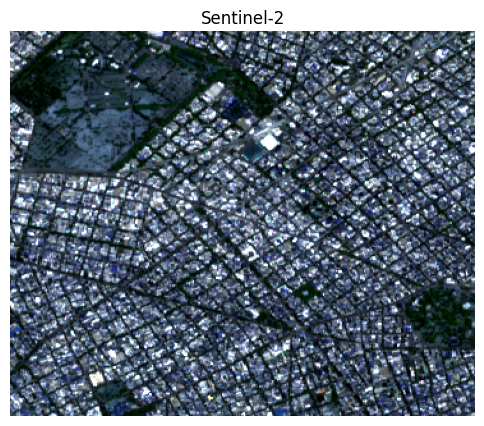

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

img_path = '/content/drive/MyDrive/earthengine/patch_300m_sentinel2_rgb.tif'

with rasterio.open(img_path) as src:
    img = src.read()

# Seleccionar bandas RGB (Bandas 4-3-2 → índices 3,2,1)
r = img[3 - 1].astype(np.float32)
g = img[2 - 1].astype(np.float32)
b = img[1 - 1].astype(np.float32)

# Apilar en eje de color
rgb = np.stack([r, g, b], axis=-1)

# Normalización usando percentiles
p2, p98 = np.percentile(rgb, (2, 98))
rgb_norm = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# Mostrar
plt.figure(figsize=(6,6))
plt.imshow(rgb_norm)
plt.axis('off')
plt.title('Sentinel-2')
plt.show()

# Nueva imagen scrapeada

In [21]:
from google.colab import userdata
import json

!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {
    'username': userdata.get('KAGGLE_USER'),
    'key': userdata.get('KAGGLE_KEY')}
with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json


import kagglehub
path = kagglehub.dataset_download("leonardocaravaggio/ge-images5")

mkdir: cannot create directory ‘/root/.kaggle’: File exists


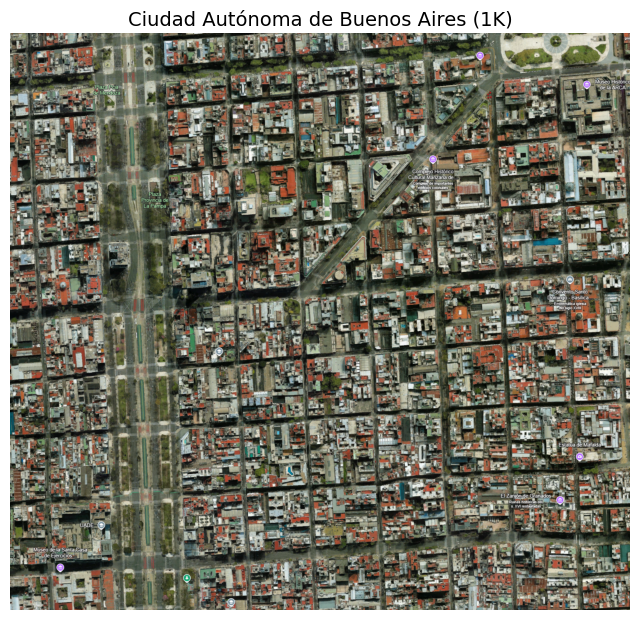

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Simulación de nombre de archivo (asegurate que `ciudades.Nombre_Aglomerado[i]` esté definido)
nombre_aglomerado = "Ciudad Autónoma de Buenos Aires"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_1km = ruta_completa + " - 1K.png"

# Cargar imagen
img = mpimg.imread(img_1km)

# Mostrar imagen
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(nombre_aglomerado + ' (1K)', fontsize=14)
plt.show()

In [8]:
import matplotlib.image as mpimg

# Cargar imagen
img = mpimg.imread(img_1km)

# Obtener dimensiones
alto, ancho = img.shape[:2]
pixeles_totales = alto * ancho

# Definir ancho real en metros (1 km)
ancho_metros = 1_000  # 1 km

# Calcular resolución espacial (m/píxel)
resolucion_m_por_pixel = ancho_metros / ancho

# Mostrar resultados
print(f"Dimensiones: {ancho} x {alto} píxeles")
print(f"Total de píxeles: {pixeles_totales:,}")
print(f"Resolución espacial: {resolucion_m_por_pixel:.2f} metros por píxel")

Dimensiones: 1904 x 1773 píxeles
Total de píxeles: 3,375,792
Resolución espacial: 0.53 metros por píxel


# Inferencia

In [9]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 89.4 MB/s eta 0:00:00


## Inferencia de una imagen

In [11]:
import torch.nn as nn
import torch.optim as optim

# U-Net simplificado
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
import numpy as np
import matplotlib.image as mpimg
from skimage.transform import resize
import tensorflow as tf
import torch

def process_image(img_path, factor, patch_size=128):
    # Cargar imagen PNG RGB
    img = mpimg.imread(img_path).astype(np.float32)

    # Eliminar canal alfa si existe
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    # Remuestrear
    img_resized = resize(img, (img.shape[0] // factor, img.shape[1] // factor, 3),
                         preserve_range=True, anti_aliasing=True).astype(np.float32)

    # Seleccionar parche central
    H, W, _ = img_resized.shape
    start_y = (H - patch_size) // 2
    start_x = (W - patch_size) // 2
    patch = img_resized[start_y:start_y + patch_size, start_x:start_x + patch_size, :]

    return patch

def generar_nir_desde_rgb(patch_rgb, model, device):
    """Recibe una imagen RGB de shape (H, W, 3) y devuelve una banda NIR normalizada (H, W)."""
    tensor_rgb = torch.from_numpy(patch_rgb.transpose(2, 0, 1)).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred_nir = model(tensor_rgb).squeeze().cpu().numpy()  # shape (H, W)
    return pred_nir

In [16]:
factor = 4
patch_size = 128

nombre_aglomerado = "Gran La Plata"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_1km = ruta_completa + " - 1K.png"
img_10km = ruta_completa + " - 5K.png"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetGenerator().to(device)
model.load_state_dict(torch.load("unet_rgb2nir.pth", map_location=device))
model.eval()

# Procesar ambas imágenes
patch_1km = process_image(img_1km, factor, patch_size)  # (128, 128, 3)
patch_10km = process_image(img_10km, factor, patch_size)  # (128, 128, 3)

# Predecir NIR para ambas imágenes
nir_1km = generar_nir_desde_rgb(patch_1km, model, device)
nir_10km = generar_nir_desde_rgb(patch_10km, model, device)

# Construir parche con 8 canales
parche_8 = np.zeros((patch_size, patch_size, 8), dtype=np.float32)

# Canales 0,1,2 = patch_1km RGB
parche_8[:, :, 0:3] = patch_1km
# Canal 3 = NIR generado a partir de patch_1km
parche_8[:, :, 3] = nir_1km

# Canales 4,5,6 = patch_10km RGB
parche_8[:, :, 4:7] = patch_10km
# Canal 7 = NIR generado a partir de patch_10km
parche_8[:, :, 7] = nir_10km

# Asegurar que no haya NaNs
parche_8 = np.nan_to_num(parche_8, nan=0.0)

# Inferencia
input_tensor = tf.convert_to_tensor(parche_8[np.newaxis, ...], dtype=tf.float32)  # (1,128,128,8)
raw_output = layer(input_tensor, training=False)

# Obtener predicción
if isinstance(raw_output, dict):
    preds = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
else:
    preds = raw_output.numpy().squeeze()

print(f"Predicción del modelo: {preds:.4f}")

Predicción del modelo: -1.0266


## Gini ??

Tamaño de imagen: 1773 x 1904
Predicciones obtenidas: (100,)
Gini de desigualdad urbana: 0.1644


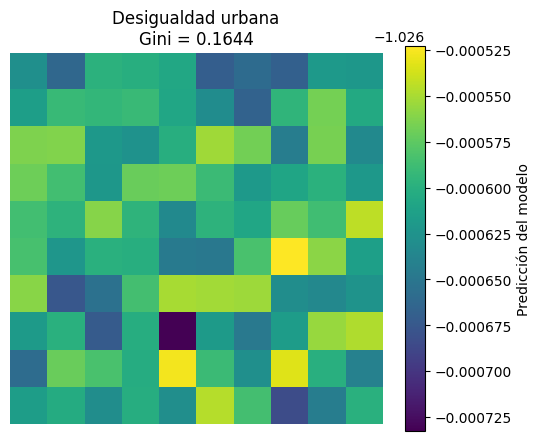

In [17]:
import numpy as np
import matplotlib.image as mpimg
import tensorflow as tf
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import tensorflow as tf
import torch

# Definiciones previas
n_patches = 10
patch_size = 128
factor = 4

# Cargar modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetGenerator().to(device)
model.load_state_dict(torch.load("unet_rgb2nir.pth", map_location=device))
model.eval()

def generar_nir_desde_rgb(patch_rgb, model, device):
    tensor_rgb = torch.from_numpy(patch_rgb.transpose(2, 0, 1)).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred_nir = model(tensor_rgb).squeeze().cpu().numpy()
    return pred_nir

# Cargar ambas imágenes
nombre_aglomerado = "Gran La Plata"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_1km = mpimg.imread(ruta_completa + " - 1K.png").astype(np.float32)
img_10km = mpimg.imread(ruta_completa + " - 10K.png").astype(np.float32)

# Eliminar canal alfa si lo tienen
if img_1km.shape[-1] == 4: img_1km = img_1km[:, :, :3]
if img_10km.shape[-1] == 4: img_10km = img_10km[:, :, :3]

H, W, _ = img_1km.shape
patch_H, patch_W = H // n_patches, W // n_patches

print(f"Tamaño de imagen: {H} x {W}")

preds = []

for i in range(n_patches):
    for j in range(n_patches):
        # Patch de imagen 1km
        p1 = img_1km[i*patch_H:(i+1)*patch_H, j*patch_W:(j+1)*patch_W, :]
        p1_resized = tf.image.resize(p1, (patch_size, patch_size)).numpy()
        nir1 = generar_nir_desde_rgb(p1_resized, model, device)

        # Patch de imagen 10km
        p2 = img_10km[i*patch_H:(i+1)*patch_H, j*patch_W:(j+1)*patch_W, :]
        p2_resized = tf.image.resize(p2, (patch_size, patch_size)).numpy()
        nir2 = generar_nir_desde_rgb(p2_resized, model, device)

        # Armar parche con 8 canales: RGB+NIR de 1km, luego RGB+NIR de 10km
        patch_8 = np.zeros((patch_size, patch_size, 8), dtype=np.float32)
        patch_8[:, :, 0:3] = p1_resized
        patch_8[:, :, 3] = nir1
        patch_8[:, :, 4:7] = p2_resized
        patch_8[:, :, 7] = nir2

        # Asegurar que no haya NaNs
        patch_8 = np.nan_to_num(patch_8)

        # Inferencia
        input_tensor = tf.convert_to_tensor(patch_8[np.newaxis, ...], dtype=tf.float32)
        raw_output = layer(input_tensor, training=False)

        # Obtener predicción
        if isinstance(raw_output, dict):
            pred = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
        else:
            pred = raw_output.numpy().squeeze()

        preds.append(pred)

# Convertimos a array
preds = np.array(preds)
print(f"Predicciones obtenidas: {preds.shape}")

# Gini
def gini(array):
    array = np.array(array, dtype=np.float32)
    if np.amin(array) < 0:
        array -= np.amin(array)
    array += 1e-8
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

gini_value = gini(preds)
print(f"Gini de desigualdad urbana: {gini_value:.4f}")

# Visualización
preds_grid = preds.reshape((n_patches, n_patches))

plt.figure(figsize=(6, 5))
plt.imshow(preds_grid, cmap='viridis')
plt.colorbar(label='Predicción del modelo')
plt.title(f'Desigualdad urbana\nGini = {gini_value:.4f}')
plt.axis('off')
plt.show()


In [19]:
import pandas as pd
ciudades=pd.read_csv("Gini_EPH.csv")

Esta próxima celda es la que habría que modificar. El gini anterior también está mal en todo caso. La idea sería partir la imagen de 10km o la de 15km en patches de 10 y poner un centro de esa misma imagen.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import tensorflow as tf
import torch
from tqdm import tqdm
from PIL import Image

# Modelo UNet para generar NIR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetGenerator().to(device)
model.load_state_dict(torch.load("unet_rgb2nir.pth", map_location=device))
model.eval()

# Asegurate de tener tu modelo de desigualdad ya cargado como 'layer'

def process_image(filepath, factor, patch_size):
    """Procesa imagen RGB: recorta centro y escala a patch_size."""
    img = mpimg.imread(filepath).astype(np.float32)
    if img.shape[-1] == 4:
        img = img[:, :, :3]
    H, W, _ = img.shape
    center_y, center_x = H // 2, W // 2
    half = patch_size * factor // 2
    cropped = img[center_y - half:center_y + half, center_x - half:center_x + half, :]
    resized = tf.image.resize(cropped, (patch_size, patch_size)).numpy()
    return resized

def generar_nir_desde_rgb(rgb_img, model, device):
    tensor_img = torch.from_numpy(rgb_img.transpose(2, 0, 1)).unsqueeze(0).to(device)  # (1, 3, H, W)
    with torch.no_grad():
        nir_pred = model(tensor_img).cpu().squeeze().numpy()  # (H, W)
    return nir_pred

def gini(array):
    array = np.array(array, dtype=np.float32)
    if np.amin(array) < 0:
        array -= np.amin(array)
    array += 1e-8
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

factor = 4
patch_size = 128
n_patches = 10
ext_A = " - 5K.png"
ext_B = " - 15K.png"

ciudades['Desigualdad_Abbate'] = np.nan

for i in tqdm(range(len(ciudades)), desc="Procesando ciudades"):
    if pd.isna(ciudades.loc[i, "Desigualdad_Abbate"]):
        try:
            nombre_archivo = ciudades.Nombre_Aglomerado[i].replace("/", ".").replace(":", "_").replace("'", "!")
            ruta_completa = os.path.join(path, nombre_archivo)

            imagenA_path = ruta_completa + ext_A
            imagenB_path = ruta_completa + ext_B

            # Abrir las dos imágenes
            imagenA = mpimg.imread(imagenA_path).astype(np.float32)
            imagenB = mpimg.imread(imagenB_path).astype(np.float32)
            if imagenA.shape[-1] == 4:
                imagenA = imagenA[:, :, :3]
            if imagenB.shape[-1] == 4:
                imagenB = imagenB[:, :, :3]

            H, W, _ = imagenA.shape
            patch_H = H // n_patches
            patch_W = W // n_patches

            preds = []

            for r in range(n_patches):
                for c in range(n_patches):
                    patchA = imagenA[r * patch_H:(r + 1) * patch_H, c * patch_W:(c + 1) * patch_W, :]
                    patchB = imagenB[r * patch_H:(r + 1) * patch_H, c * patch_W:(c + 1) * patch_W, :]

                    # Resize
                    patch_1_resized = tf.image.resize(patchA, (patch_size, patch_size)).numpy()
                    patch_2_resized = tf.image.resize(patch, (patch_size, patch_size)).numpy()

                    # Generar NIRs
                    nir_1 = generar_nir_desde_rgb(patch_1_resized, model, device)
                    nir_2 = generar_nir_desde_rgb(patch_2_resized, model, device)

                    # Crear input de 8 canales
                    patch_8 = np.zeros((patch_size, patch_size, 8), dtype=np.float32)
                    patch_8[:, :, 0:3] = patch_1_resized
                    patch_8[:, :, 3] = nir_1
                    patch_8[:, :, 4:7] = patch_2_resized
                    patch_8[:, :, 7] = nir_2

                    patch_8 = np.nan_to_num(patch_8)

                    # Inference
                    input_tensor = tf.convert_to_tensor(patch_8[np.newaxis, ...], dtype=tf.float32)
                    raw_output = layer(input_tensor, training=False)

                    # Extraer predicción
                    if isinstance(raw_output, dict):
                        pred = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
                    else:
                        pred = raw_output.numpy().squeeze()

                    preds.append(pred)

            # Gini
            gini_value = gini(preds)
            ciudades.loc[i, "Desigualdad_Abbate"] = gini_value

        except Exception as e:
            print(f"Error en {ciudades.Nombre_Aglomerado[i]}: {e}")

In [37]:
ciudades.head(2)

,Unnamed: 0,AGLOMERADO,Nombre_Aglomerado,Gini_Personas,Gini_Hogares,Desigualdad_Abbate
0,0,2,Gran La Plata,0.477884,0.430569,0.227670
1,25,32,Ciudad Autónoma de Buenos Aires,0.405170,0.415689,0.207925


In [38]:
from scipy.stats import pearsonr

# Eliminar pares con NaN
x = ciudades["Desigualdad_Abbate"]
y = ciudades["Gini_Personas"]
mask = x.notna() & y.notna()

# Calcular correlación de Pearson y p-value
r, p = pearsonr(x[mask], y[mask])

print(f"Coeficiente de Pearson: {r:.3f}")
print(f"Valor p: {p:.5f}")

Coeficiente de Pearson: 0.086
Valor p: 0.63794


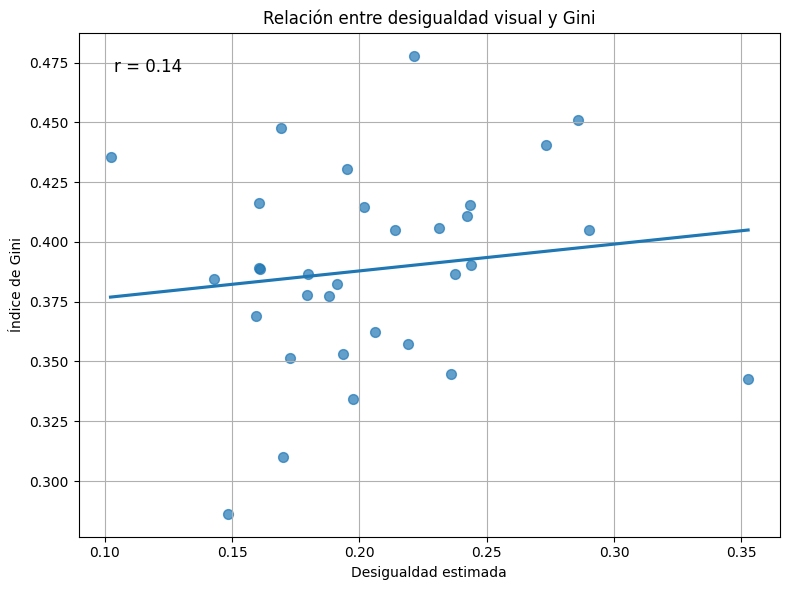

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Filtrar datos válidos
x = ciudades["Desigualdad_Abbate"]
y = ciudades["Gini_Personas"]
mask = x.notna() & y.notna()
x_valid = x[mask]
y_valid = y[mask]

# Calcular correlación
r, p = pearsonr(x_valid, y_valid)

# Determinar nivel de significancia
if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = ""

# Crear gráfico
plt.figure(figsize=(8, 6))
sns.regplot(x=x_valid, y=y_valid, ci=None, scatter_kws={"s": 50, "alpha": 0.7})

# Anotar r y p
plt.text(0.05, 0.95, f"r = {r:.2f}{stars}", ha="left", va="top", transform=plt.gca().transAxes, fontsize=12)

plt.xlabel("Desigualdad estimada")
plt.ylabel("Índice de Gini")
plt.title("Relación entre desigualdad visual y Gini")
plt.grid(True)
plt.tight_layout()
plt.show()